# Pill Imprint OCR_baseline

## 0. Colab setup & 패키지 설치

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Paddle 패키지 설치
!pip uninstall -y torch torchvision torchaudio modelscope
!pip install paddlepaddle-gpu==3.1.0 -i \
    https://www.paddlepaddle.org.cn/packages/stable/cu118/
!pip install "paddleocr>=3.0.0"

Found existing installation: torch 2.11.0+cu128
Uninstalling torch-2.11.0+cu128:
  Successfully uninstalled torch-2.11.0+cu128
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
Looking in indexes: https://www.paddlepaddle.org.cn/packages/stable/cu118/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 GB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 37.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 45.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 699.9/699.9 MB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
!pip install -q opencv-python-headless pandas numpy matplotlib tqdm

In [4]:
# 설치 후 런타임 재시작 없이 바로 import 가능한지 확인
import importlib, sys

required = ["cv2", "numpy", "pandas", "paddleocr"]
missing  = [m for m in required if importlib.util.find_spec(m) is None]
if missing:
    print(f"[ERROR] 미설치 모듈: {missing} — 런타임 재시작 후 다시 실행하세요.")
else:
    print("모든 패키지 import 가능.")

모든 패키지 import 가능.


In [5]:
from __future__ import annotations

import re
import zipfile
from pathlib import Path
from typing import Optional

import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

## 1. 경로 설정

In [6]:
DRIVE_BASE   = Path("/content/drive/MyDrive/Pillot/yoonsoo")

# 입력: crop된 이미지 zip + manifest
CROP_ZIP     = DRIVE_BASE / "crop_v2_val.zip"
MANIFEST_CSV = DRIVE_BASE / "crop_v2_manifest.csv"

# 압축 해제 경로 (Colab 로컬 — Drive I/O 병목 방지)
CROP_DIR     = Path("/content/crops_v2_val")

# 결과 저장
RESULT_DIR   = DRIVE_BASE / "results"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print(f"CROP_ZIP    : {CROP_ZIP}  (exists={CROP_ZIP.exists()})")
print(f"MANIFEST_CSV: {MANIFEST_CSV}  (exists={MANIFEST_CSV.exists()})")

CROP_ZIP    : /content/drive/MyDrive/Pillot/yoonsoo/crop_v2_val.zip  (exists=True)
MANIFEST_CSV: /content/drive/MyDrive/Pillot/yoonsoo/crop_v2_manifest.csv  (exists=True)


In [7]:
# zip 압축 해제 (이미 해제됐으면 스킵)
if not CROP_DIR.exists() or not any(CROP_DIR.iterdir()):
    CROP_DIR.mkdir(parents=True, exist_ok=True)
    print("압축 해제 중...")
    with zipfile.ZipFile(CROP_ZIP, "r") as zf:
        zf.extractall(CROP_DIR)
    print(f"완료: {sum(1 for _ in CROP_DIR.rglob('*.png'))}개 이미지")
else:
    n = sum(1 for _ in CROP_DIR.rglob('*.png'))
    print(f"이미 해제됨: {n}개 이미지")

압축 해제 중...
완료: 7456개 이미지


## 2. Manifest 로드 & target 정규화

In [8]:
IGNORE_IMPRINT_TOKENS = {
    "", "NAN", "NONE", "NULL", "마크", "분할선", "없음", "무", "-",
}

_RE_STRIP_TOKENS = re.compile(r"\s+|분할선|마크|\|")
_RE_ALLOWED      = re.compile(r"[^0-9A-Z가-힣+\-/]")


def normalize_imprint(text: object) -> str:
    if pd.isna(text):
        return ""
    text = str(text).strip().upper()
    if text in IGNORE_IMPRINT_TOKENS:
        return ""
    text = _RE_STRIP_TOKENS.sub("", text)
    text = _RE_ALLOWED.sub("", text)
    if text in IGNORE_IMPRINT_TOKENS:
        return ""
    return text


def build_target_for_row(row: pd.Series) -> dict:
    front = normalize_imprint(row.get("print_front", ""))
    back  = normalize_imprint(row.get("print_back",  ""))
    candidates = list(dict.fromkeys(t for t in [front, back] if t))

    return {
        "target_text_front": front,
        "target_text_back":  back,
        "target_candidates": candidates,
        "target_text":       "/".join(candidates),
    }


# drug_dir 분기 버전
#    drug_dir = str(row.get("drug_dir", "")).strip()

#    if drug_dir == "앞면" and front:
#        candidates = [front]
#    elif drug_dir == "뒷면" and back:
#        candidates = [back]
#    else:
#        candidates = list(dict.fromkeys(t for t in [front, back] if t))

In [9]:
# manifest 로드
df_manifest = pd.read_csv(MANIFEST_CSV, low_memory=False)
df_manifest = df_manifest[df_manifest["split"] == "val"].reset_index(drop=True)  # val만 사용

print(f"manifest 로드: {df_manifest.shape}")

# 변수 확인
print((df_manifest.columns).tolist())

# df_manifest["crop_path"] 의 각 값을 받아서 파일명만 추출한 뒤 CROP_DIR 앞에 붙여줌
def remap_crop_path(p: str, crop_dir: Path) -> Path:
    return crop_dir / Path(p).name

df_manifest["crop_path"] = df_manifest["crop_path"].apply(
    lambda p: str(remap_crop_path(str(p), CROP_DIR))
)

# target 컬럼 추가
target_cols = df_manifest.apply(build_target_for_row, axis=1, result_type="expand")
df_manifest = pd.concat([df_manifest, target_cols], axis=1)

# crop 파일 존재 확인
df_manifest["_crop_exists"] = df_manifest["crop_path"].apply(lambda p: Path(str(p)).exists())
ok   = df_manifest["_crop_exists"].sum()
miss = len(df_manifest) - ok
print(f"crop 파일 확인: {ok} 존재 / {miss} 누락")

df = df_manifest[df_manifest["_crop_exists"]].reset_index(drop=True)
print(f"사용 가능: {len(df)}건")
display(df[["image_file", "crop_path","target_text_front", "target_text_back","target_candidates","target_text"]])

manifest 로드: (7456, 58)
['split', 'dataset_type', 'image_file', 'image_rel_path', 'width', 'height', 'item_seq', 'dl_mapping_code', 'dl_name', 'dl_name_en', 'dl_company', 'dl_material', 'dl_material_en', 'drug_dir', 'drug_shape', 'color_class1', 'color_class2', 'line_front', 'line_back', 'print_front', 'print_back', 'has_print_front', 'has_print_back', 'has_any_print', 'ocr_text', 'has_ocr_text_for_current_side', 'bbox_x', 'bbox_y', 'bbox_w', 'bbox_h', 'area', 'category_id', 'label_zip_name', 'json_file', 'split_type', 'form_code_name', 'staging_id', 'chart', 'di_class_no', 'di_etc_otc_code', 'di_edi_code', 'back_color', 'light_color', 'camera_la', 'camera_lo', 'size', 'created_at', 'color_group_normalized', 'shape_group_unified', 'line_binary_unified', 'object_id', 'color_class1_original', 'color_class2_original', 'drug_shape_original', 'pool_name', 'component_id', 'image_item_seq_count', 'crop_path']
crop 파일 확인: 7456 존재 / 0 누락
사용 가능: 7456건


,image_file,crop_path,target_text_front,target_text_back,target_candidates,target_text
0,K-020582_0_0_0_2_75_020_200.png,/content/crops_v2_val/000016_K-020582_0_0_0_2_...,GS5YZ,,[GS5YZ],GS5YZ
1,K-020582_0_1_1_2_60_060_200.png,/content/crops_v2_val/000017_K-020582_0_1_1_2_...,GS5YZ,,[GS5YZ],GS5YZ
2,K-020582_0_2_0_2_75_140_200.png,/content/crops_v2_val/000018_K-020582_0_2_0_2_...,GS5YZ,,[GS5YZ],GS5YZ
3,K-020006_0_0_0_1_90_080_200.png,/content/crops_v2_val/000019_K-020006_0_0_0_1_...,LDT,,[LDT],LDT
4,K-020006_0_0_1_1_70_340_200.png,/content/crops_v2_val/000020_K-020006_0_0_1_1_...,LDT,,[LDT],LDT
...,...,...,...,...,...,...
7451,K-012778-022362-025438-038954_0_2_0_2_75_000_2...,/content/crops_v2_val/029803_K-012778-022362-0...,MCWBR,,[MCWBR],MCWBR
7452,K-013395-019552-025438-037777_0_2_0_2_75_000_2...,/content/crops_v2_val/029816_K-013395-019552-0...,Q,YH,"[Q, YH]",Q/YH
7453,K-013395-019552-025438-037777_0_2_0_2_75_000_2...,/content/crops_v2_val/029817_K-013395-019552-0...,HTEDT,,[HTEDT],HTEDT
7454,K-013395-019552-025438-037777_0_2_0_2_75_000_2...,/content/crops_v2_val/029818_K-013395-019552-0...,SUSPENER,,[SUSPENER],SUSPENER


## 3. 전처리 (denoise + CLAHE 대비 강화)

- AWB: crop 생성 시 이미 적용 → **제거**
- resize: PaddleOCR 내부 처리 → **제거**
- bilateral denoise + CLAHE를 단일 함수로 통합

In [37]:
from dataclasses import dataclass


@dataclass
class PrepConfig:
    # denoise
    denoise_method: str = "none"   # "none" | "bilateral" | "nlm"
    bilateral_d: int = 3
    bilateral_sigma_color: int = 20
    bilateral_sigma_space: int = 20
    nlm_h: int = 3
    # CLAHE
    clahe_clip: float = 2.5
    clahe_tile: int = 8
    # unsharp
    unsharp_strength: float = 1.0   # 0이면 비활성화
    unsharp_sigma: float = 1.5      # 블러 반경


def preprocess_crop(image_bgr: np.ndarray, cfg: PrepConfig = PrepConfig()) -> np.ndarray:
    """
    denoise → CLAHE 대비 강화 파이프라인.
    - AWB 없음 (crop 생성 시 적용 완료)
    - resize 없음 (PaddleOCR 내부 처리)
    반환: BGR 3채널 (PaddleOCR 입력 규격)
    """
    out = image_bgr

    # 1) denoise
    if cfg.denoise_method == "bilateral":
        out = cv2.bilateralFilter(out, cfg.bilateral_d,
                                  cfg.bilateral_sigma_color, cfg.bilateral_sigma_space)
    elif cfg.denoise_method == "nlm":
        out = cv2.fastNlMeansDenoisingColored(out, None, cfg.nlm_h, cfg.nlm_h, 7, 21)

    # 2) CLAHE (grayscale에 적용 → BGR 복원)
    gray  = cv2.cvtColor(out, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=cfg.clahe_clip,
                             tileGridSize=(cfg.clahe_tile, cfg.clahe_tile))
    enhanced = clahe.apply(gray)

    # 3) Unsharp mask
    if cfg.unsharp_strength > 0:
        blurred = cv2.GaussianBlur(enhanced, (0, 0), cfg.unsharp_sigma)
        enhanced = cv2.addWeighted(enhanced, 1 + cfg.unsharp_strength,
                                   blurred, -cfg.unsharp_strength, 0)

    return cv2.cvtColor(enhanced, cv2.COLOR_GRAY2BGR)


def load_and_preprocess(crop_path: str, cfg: PrepConfig = PrepConfig()) -> np.ndarray:
    img = cv2.imread(crop_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise FileNotFoundError(crop_path)
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    elif img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)
    return preprocess_crop(img, cfg)

## 4. PaddleOCR 초기화

> **환경 주의사항**
> - `use_angle_cls=True` : 생략(3.x에서는 디폴트)
> - `lang='korean'` : 한/영 혼용 인식
> - `device="gpu"` : Colab GPU 사용 (없으면 `False` 로 변경)
> - PaddleOCR 객체는 **한 번만** 생성 (셀 재실행 시 중복 초기화 방지 → `_ocr` 변수 체크)

In [11]:
import paddle
print(f"PaddlePaddle version : {paddle.__version__}")
print(f"GPU available        : {paddle.is_compiled_with_cuda()}")
print(f"GPU count            : {paddle.device.cuda.device_count()}")

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:715: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


PaddlePaddle version : 3.1.0
GPU available        : True
GPU count            : 1


In [ ]:
# "PaddleOCR 이미 초기화됨 — 재사용" 시에만 사용
del _ocr

In [12]:
from paddleocr import PaddleOCR

# 중복 초기화 방지: 셀을 여러 번 실행해도 한 번만 생성
# use_angle_cls: 3.x 에서 내부적으로 항상 활성화
if "_ocr" not in globals():
    _ocr = PaddleOCR(
        device="gpu",
        use_doc_orientation_classify= True, # 문서 전체 회전 보정 on/off 선택
        use_doc_unwarping= False,   # 문서 휘어짐 보정 on/off 선택
        use_textline_orientation=True,  # 텍스트 라인 단위 회전 보정 on/off 선택
        text_detection_model_name="PP-OCRv5_server_det",   # 모델 변경: mobile -> server
        text_recognition_model_name="PP-OCRv5_server_rec",
    )
    print("PaddleOCR 초기화 완료")
else:
    print("PaddleOCR 이미 초기화됨 — 재사용")

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Using official model (PP-LCNet_x1_0_textline_ori), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-OCRv5_server_det', None, None)
Using official model (PP-OCRv5_server_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_server_det`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-OCRv5_server_rec', None, None)
Using official model (PP-OCRv5_server_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_server_rec`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

PaddleOCR 초기화 완료


## 5. paddle OCR 구현

In [38]:
prep_cfg = PrepConfig()

def run_ocr_on_row(row: pd.Series, ocr, cfg: PrepConfig) -> dict:
    result = {
        "image_file":  row["image_file"],
        "crop_path":   row["crop_path"],
        "target_text": row.get("target_text", ""),
        "ocr_raw":     "",
        "ocr_text":    "",
        "ocr_conf":    float("nan"),
        "error":       "",
    }
    try:
        img        = load_and_preprocess(row["crop_path"], cfg)  # 전처리 적용
        ocr_result = ocr.predict(img, text_det_thresh=0.3)
        if ocr_result:
            page  = ocr_result[0]
            texts = [str(t) for t in page.get("rec_texts", [])]
            confs = [float(c) for c in page.get("rec_scores", [])]
            if texts:
                result["ocr_raw"]  = " | ".join(texts)
                result["ocr_text"] = "".join(texts).strip()
                result["ocr_conf"] = float(np.mean(confs))
                result["ocr_raw"]  = " | ".join(texts)
                result["ocr_text"] = normalize_imprint("".join(texts).strip())
    except Exception as exc:
        result["error"] = str(exc)
    return result

records = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="OCR (val)"):
    records.append(run_ocr_on_row(row, _ocr, prep_cfg))

df_result = pd.DataFrame(records)
print(f"\n완료: {len(df_result)}건  오류: {df_result['error'].ne('').sum()}건")
display(df_result[["image_file", "target_text", "ocr_raw", "ocr_text"]])

OCR (val):   0%|          | 0/7456 [00:00<?, ?it/s]


완료: 7456건  오류: 0건


,image_file,target_text,ocr_raw,ocr_text
0,K-020582_0_0_0_2_75_020_200.png,GS5YZ,Z5,Z5
1,K-020582_0_1_1_2_60_060_200.png,GS5YZ,,
2,K-020582_0_2_0_2_75_140_200.png,GS5YZ,GS | 5YZ,GS5YZ
3,K-020006_0_0_0_1_90_080_200.png,LDT,LDT,LDT
4,K-020006_0_0_1_1_70_340_200.png,LDT,,
...,...,...,...,...
7451,K-012778-022362-025438-038954_0_2_0_2_75_000_2...,MCWBR,MCW,MCW
7452,K-013395-019552-025438-037777_0_2_0_2_75_000_2...,Q/YH,,
7453,K-013395-019552-025438-037777_0_2_0_2_75_000_2...,HTEDT,HT | EDT,HTEDT
7454,K-013395-019552-025438-037777_0_2_0_2_75_000_2...,SUSPENER,83 | NEGSAS,83NEGSAS


# 5-1. 이미지 및 manifest 검색

In [ ]:
# 전처리 완료 버전 이미지 확인(target_file에 확인하고 싶은 image_file 삽입)
import matplotlib.pyplot as plt

target_file = "K-035452_0_2_1_2_75_140_200.png"
row = df[df["image_file"] == target_file].iloc[0]

img_preprocessed = load_and_preprocess(row["crop_path"])

plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(img_preprocessed, cv2.COLOR_BGR2RGB))
plt.title(f"{target_file}\ntarget: {row['target_text']}")
plt.axis("off")
plt.show()

In [ ]:
# manifest 행 검색
display(df[df["image_file"] == "K-003544-012420-016551-029345_0_2_0_2_90_000_200.png"].T)

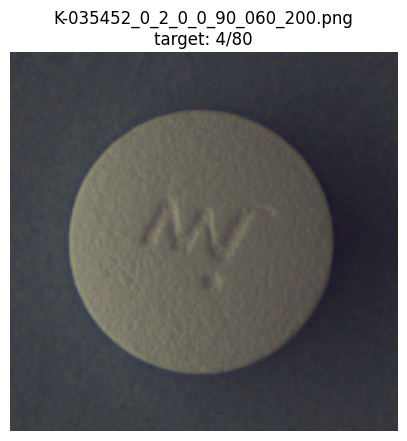

In [ ]:
# image_file에 대한 원본 이미지 확인
row = df[df["image_file"] == "K-035452_0_2_0_0_90_060_200.png"].iloc[0]

# 원본 (전처리 전)
img_orig = cv2.imread(row["crop_path"])

plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
plt.title(f"{row['image_file']}\ntarget: {row['target_text']}")
plt.axis("off")
plt.show()

## 6. 정확도 확인

In [40]:
# ── 1. combination 중복 행 문제 해결 ─────────────────────────────────────
# image_file 기준으로 groupby 후 중복 제거하여 후보 리스트로 합침
cand_map = (
    df.groupby("image_file")["target_candidates"]
    .apply(lambda x: list(dict.fromkeys(c for cands in x for c in cands)))
    .to_dict()
)

# ── 2. 평가 함수 정의 ─────────────────────────────────────────────────────
# Candidate Match: 정규화된 예측값이 후보 목록 중 하나와 정확히 일치하는지 확인

def candidate_match(pred: str, candidates) -> bool:
    if not isinstance(candidates, list):
        return False
    pred_norm = normalize_imprint(pred)
    return any(pred_norm == c for c in candidates)

def cer(pred: str, target: str) -> float:
    if not target:
        return float("nan")
    p, t = list(pred), list(target)
    dp = list(range(len(t) + 1))
    for pc in p:
        ndp = [dp[0] + 1]
        for j, tc in enumerate(t):
            ndp.append(min(dp[j] + (pc != tc), dp[j+1] + 1, ndp[-1] + 1))
        dp = ndp
    return dp[len(t)] / len(t)

# ── 3. dataset_type 컬럼 병합 ─────────────────────────────────────────────
# single / combination 구분값을 결과 df에 추가
# 없을 경우에만 merge 하는 조건문을 추가하여 run할 때마다 행이 늘어나는 문제 방지
if "dataset_type" not in df_result.columns:
    df_result = df_result.merge(
        df[["image_file", "dataset_type"]].drop_duplicates("image_file"),
        on="image_file", how="left"
    )


# ── 4. 지표 계산 ──────────────────────────────────────────────────────────
# Candidate Match: single + combination 전체 대상
df_result["cand_match"] = df_result.apply(
    lambda r: candidate_match(r["ocr_text"], cand_map.get(r["image_file"], [])), axis=1
)

# CER: single 중 단일 후보만 계산, 그 외는 NaN 처리

single_candidate_files = set(df[df["target_candidates"].apply(len) == 1]["image_file"])

df_result["cer"] = df_result.apply(
    lambda r: cer(r["ocr_text"], normalize_imprint(r["target_text"]))
    if r["dataset_type"] == "single" and r["image_file"] in single_candidate_files
    else float("nan"),
    axis=1
)

valid_cand = df_result["target_text"].ne("")
valid_cer = (
    (df_result["dataset_type"] == "single") &
    df_result["target_text"].ne("") &
    df_result["image_file"].isin(single_candidate_files)
    )


# ── 5. 결과 출력 ──────────────────────────────────────────────────────────
print("=" * 40)
print(f"전체 {len(df_result)}건 중 target 있는 것: {valid_cand.sum()}건")
print(f"Candidate Match ({valid_cand.sum()}건, single+combination)")
print(f"  : {df_result.loc[valid_cand, 'cand_match'].mean():.3f}")
print(f"CER ({valid_cer.sum()}건, single only)")
print(f"  : {df_result.loc[valid_cer, 'cer'].mean():.3f}")
print(f"오류 건수: {df_result['error'].ne('').sum()}")
print("=" * 40)

전체 7456건 중 target 있는 것: 7165건
Candidate Match (7165건, single+combination)
  : 0.348
CER (2528건, single only)
  : 0.763
오류 건수: 0


In [ ]:
# Candidate Match 성공 리스트 확인
df_cm = df_result[df_result["cand_match"] == True]
print(f"Candidate Match 정답 {len(df_cm)}건")
display(df_cm[["image_file", "target_text", "ocr_raw", "ocr_text", "cand_match", "cer" ]])

Candidate Match 정답 2421건


,image_file,target_text,ocr_raw,ocr_text,cand_match,cer
2,K-020582_0_2_0_2_75_140_200.png,GS5YZ,GS | 5YZ,GS5YZ,True,0.0
3,K-020006_0_0_0_1_90_080_200.png,LDT,LDT,LDT,True,0.0
16,K-022176_0_1_1_1_70_080_200.png,DW/300,300,300,True,NaN
17,K-022176_0_1_1_0_90_260_200.png,DW/300,300,300,True,NaN
28,K-023594_0_1_1_2_70_220_200.png,KK/PI,KK,KK,True,NaN
...,...,...,...,...,...,...
7446,K-012778-022362-025438-038954_0_2_0_2_90_000_2...,YH,YH,YH,True,NaN
7448,K-012778-022362-025438-038954_0_2_0_2_90_000_2...,MX,MX,MX,True,NaN
7449,K-012778-022362-025438-038954_0_2_0_2_75_000_2...,MX,MX,MX,True,NaN
7453,K-013395-019552-025438-037777_0_2_0_2_75_000_2...,HTEDT,HT | EDT,HTEDT,True,NaN


In [ ]:
single_unique = df[
    (df["dataset_type"] == "single") &
    (df["target_candidates"].apply(len) == 1) &
    df["target_text"].ne("")
]
print(f"single + 단일 후보: {len(single_unique)}건 / single 전체: {len(df[df['dataset_type']=='single'])}건")

single + 단일 후보: 2528건 / single 전체: 3686건


In [ ]:
# 오답 케이스 확인
df_wrong = df_result[~df_result["cand_match"] & df_result["target_text"].ne("")]
print(f"오답 {len(df_wrong)}건")
display(df_wrong[["image_file", "target_text", "ocr_raw", "ocr_text"]].head(20))

오답 5808건


,image_file,target_text,ocr_raw,ocr_text
0,K-020582_0_0_0_2_75_020_200.png,GS5YZ,275,275
1,K-020582_0_1_1_2_60_060_200.png,GS5YZ,,
2,K-020582_0_2_0_2_75_140_200.png,GS5YZ,ZAL | S5,ZALS5
4,K-020006_0_0_1_1_70_340_200.png,LDT,,
5,K-020006_0_2_1_0_60_240_200.png,LDT,,
6,K-022362_0_0_0_2_70_020_200.png,MX,X√ㅣ,X
7,K-022362_0_1_1_2_90_060_200.png,MX,,
8,K-022362_0_1_1_0_75_080_200.png,MX,,
9,K-022362_0_2_0_2_75_120_200.png,MX,XN,XN
10,K-022362_0_0_1_0_60_120_200.png,MX,,


# 그 외

In [ ]:
# target 없는 행 및 이미지 관찰
display(df_result[df_result["target_text"] == ""])

empty = df["target_text"].eq("").sum()
total = len(df)
print(f"target 없음: {empty}건 / 전체 {total}건 ({empty/total*100:.1f}%)")

import matplotlib.pyplot as plt

df_empty = df[df["target_text"] == ""].reset_index(drop=True)

COLS = 5
n    = len(df_empty)
rows = (n + COLS - 1) // COLS

fig, axes = plt.subplots(rows, COLS, figsize=(COLS * 3, rows * 3))
axes = np.array(axes).flatten()

for ax, (_, row) in zip(axes, df_empty.iterrows()):
    img = cv2.imread(row["crop_path"])
    if img is not None:
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(row["image_file"][:25], fontsize=6)
    ax.axis("off")

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# df_result 중복 제거
df_result_unique = df_result.drop_duplicates("image_file", keep="first").reset_index(drop=True)

# df_check 생성
df_check = df_result_unique.merge(
    df[["image_file", "print_front", "print_back", "drug_dir"]].drop_duplicates("image_file"),
    on="image_file", how="left"
)

# drug_dir=앞면인데 ocr_text가 back 각인과 일치하는 경우(의심케이스 계산)
suspect = df_check[
    (df_check["drug_dir"] == "앞면") &
    (df_check["ocr_text"] == df_check["print_back"].apply(normalize_imprint)) &
    df_check["ocr_text"].ne("")
]

print(f"의심 케이스: {len(suspect)}건")
display(suspect[["image_file", "print_front", "print_back", "drug_dir", "ocr_text", "cand_match"]].head(20))

의심 케이스: 316건


,image_file,print_front,print_back,drug_dir,ocr_text,cand_match
36,K-023411_0_2_0_2_70_140_200.png,HM,LB,앞면,LB,False
90,K-027127_0_2_0_0_70_240_200.png,마크,P2,앞면,P2,True
91,K-027127_0_1_0_0_70_020_200.png,마크,P2,앞면,P2,True
104,K-029533_0_0_0_1_60_300_200.png,5/500,4221,앞면,4221,False
142,K-034327_0_2_0_1_75_140_200.png,ENK,TME,앞면,TME,False
152,K-033632_0_1_0_1_75_220_200.png,H분할선L,AT,앞면,AT,False
153,K-033632_0_0_0_2_75_020_200.png,H분할선L,AT,앞면,AT,False
182,K-037578_0_1_0_2_75_200_200.png,마크,5050,앞면,5050,True
183,K-037578_0_2_0_1_75_320_200.png,마크,5050,앞면,5050,True
184,K-035649_0_0_0_1_75_040_200.png,마크,CLD,앞면,CLD,True
